# SolarFarmer SDK — Energy Yield via SolarFarmer API in 90 Seconds

<span style="font-size:1.2em; color:#003591">
Specify engineering intent. The SDK builds the payload. DNV's bankable physical engine runs the numbers.<br>
Design, simulate, and optimise a 10 MW plant — in a single Python session.
</span>

---


In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import solarfarmer as sf
from solarfarmer import PVSystem

# --- DNV plot style ---
DNV = {'navy': '#0f204b', 'blue': '#003591', 'sky': '#009fda',
       'light': '#99d9f0', 'green': '#3f9c35'}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f7fbfe',
    'axes.edgecolor': DNV['navy'],
    'axes.labelcolor': DNV['navy'],
    'axes.titleweight': 'bold',
    'axes.titlecolor': DNV['blue'],
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': DNV['sky'],
    'xtick.color': DNV['navy'],
    'ytick.color': DNV['navy'],
    'font.family': 'Ubuntu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
})

SF_API_KEY = os.environ["SF_API_KEY"]
sf.configure_logging();

## Plant Design

Provide high-level engineering intent — location, capacity, mounting type, equipment, and weather. The SDK infers the remaining design details and constructs a complete, valid API payload. No JSON authoring required.


In [2]:
plant = PVSystem(
    name="Albuquerque 10 MW",
    latitude=35.10,
    longitude=-106.67,
    altitude=1510,
)

# Capacity
plant.dc_capacity_MW = 10.0
plant.ac_capacity_MW = 8.0
plant.grid_limit_MW  = 8.5

# Array — single-axis tracker
plant.mounting  = sf.MountingType.TRACKER
plant.tilt      = 60.0
plant.azimuth   = 180.0
plant.gcr       = 0.40
plant.bifacial  = True

# Inverter
plant.inverter_type      = sf.InverterType.CENTRAL
plant.transformer_stages = 1

# Losses
plant.soiling_loss = [0.04, 0.04, 0.03, 0.02, 0.02, 0.01,
                      0.01, 0.02, 0.02, 0.03, 0.04, 0.04]
plant.albedo = [0.20] * 12

# Equipment & weather
plant.add_pan_files({"TrinaSolar 375W": Path("equipment/TrinaSolar_TSM-375DE14A(II)_APP.PAN")})
plant.add_ond_files({"SMA STP 60": Path("equipment/60_10_APP02.OND")})
plant.weather_file = Path("weather_albuquerque_tmy.tsv")

print("Plant configured.")


Plant configured.


In [3]:
plant.describe(verbose=True)


PV PLANT SUMMARY

--- BASIC METADATA ---
Name: Albuquerque 10 MW
Results Available: False

--- LOCATION ---
Latitude: 35.1°
Longitude: -106.67°
Altitude: 1510 m
Timezone: UTC

--- CAPACITY ---
DC Capacity: 10.0 MW
AC Capacity: 8.0 MW
Grid Limit: 8.5 MW

--- ARRAY CONFIGURATION ---
GCR (Ground Coverage Ratio): 0.4
Pitch: None m
Tilt: 60.0°
Azimuth: 180.0°

--- MOUNTING & ORIENTATION ---
Mounting Type: MountingType.TRACKER
Module Orientation: OrientationType.PORTRAIT
Modules Across: 1
Mounting Height: 0.7 m
Flush Mount: False

--- BIFACIAL PARAMETERS ---
Bifacial Modules: True
  - Transmission Factor: 0.0
  - Shade Loss Factor: 0.0
  - Mismatch Loss Factor: 0.0

--- INVERTER & TRANSFORMER ---
Inverter Type: InverterType.CENTRAL
String Length: None modules
Transformer Stages: 1 (0=Ideal/NoLoss, 1=MV/HV transformer)

--- LOSSES ---
DC Ohmic Loss: 0.015 (per unit)
AC Ohmic Loss: 0.005 (per unit)
Module Mismatch Loss: 0.005 (per unit)
Module Quality Factor: 0.0 (per unit)
LID Loss: 0.0 (per

## Run Energy Calculation

The `describe()` output above shows the full resolved design, including string sizing, wiring, and layout geometry that were never explicitly set. Submit it as-is. The backing engine is DNV's SolarFarmer, the same model used in bankable energy assessments.


In [4]:
%%time
results = plant.run_energy_calculation(
    project_id="demo-albuquerque-10mw",
    api_key=SF_API_KEY,
    print_summary=True,
)

INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:43:38



DESIGN SUMMARY

Capacity Summary:
  Target (input) DC Capacity: 10.0 MW
  Design (output for simulation) DC Capacity: 9.996 MW
  Target (input) AC Capacity: 8.0 MW
  Design (output for simulation) AC Capacity: 8.040 MW

Layout Configuration:
  Number of Inverters: 134
  Number of Modules: 26666
  String Length: 15
  Total Strings: 2010



INFO: SUCCESS: Calculation returned successfully (time taken: 6.0 seconds)


-------------------------------------------------------
		General site data:
-------------------------------------------------------
Project name = demo-albuquerque-10mw
Location (latitude, longitude, altitude) = 35.10000°, -106.67000°, 1510.0 m
2D/3D = 2D calculation
Mounting type = Single-axis trackers
AC capacity of system = 8.04 MW
DC capacity of system = 9.995625 MW
Run in SolarFarmer API version 6.1.0
-------------------------------------------------------
    Annual Performance Summary (project year 1, 2059)
-------------------------------------  -----------------
Average annual temperature             13.92°C
Horizontal irradiation                 2041.11 kWh/m²
Irradiation on tilted plane            2740.61 kWh/m²
Effective irradiation on tilted plane  2593.26 kWh/m²
Energy yield                           2171.42 kWh/kWp
Net energy                             21704.70 MWh/year
Performance Ratio                      0.7923
-------------------------------------  ----------------

## Results

In [5]:
perf = results.get_performance(project_year=1)

print(f"{'='*50}")
print(f"  Net energy:         {perf['net_energy']:,.0f} MWh/year")
print(f"  Specific yield:     {perf['energy_yield']:,.0f} kWh/kWp")
print(f"  Performance ratio:  {perf['performance_ratio']:.1%}")
print(f"  GHI:                {perf['horizontal_irradiation']:,.0f} kWh/m²")
print(f"{'='*50}")

  Net energy:         21,705 MWh/year
  Specific yield:     2,171 kWh/kWp
  Performance ratio:  79.2%
  GHI:                2,041 kWh/m²


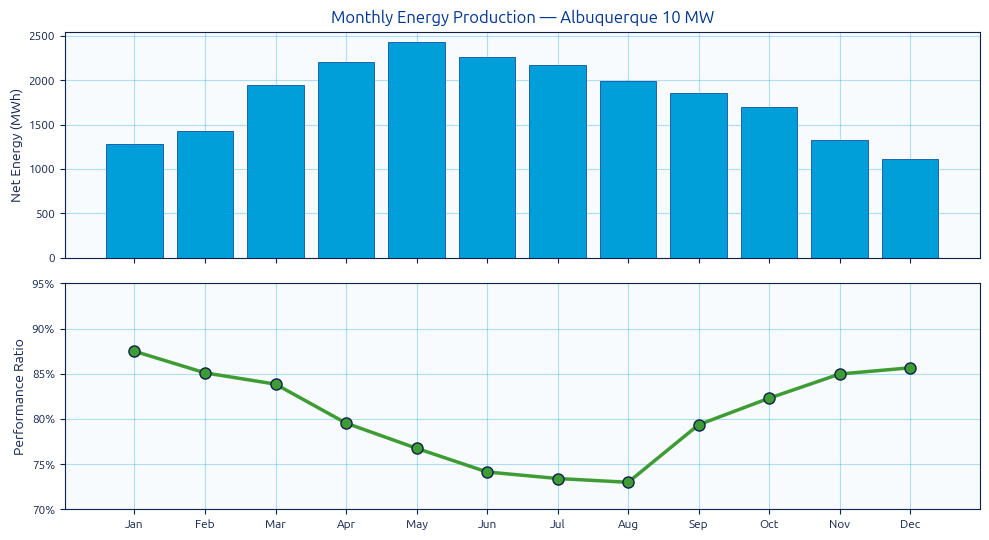

Annual total: 21,705 MWh


In [6]:
monthly_raw = results.get_monthly_results_table(include_energy_results=True, include_effects=False)
monthly_df  = pd.DataFrame(monthly_raw['energy_results'])
monthly_y1  = monthly_df[monthly_df['project_year'] == 1].sort_values('month').reset_index(drop=True)

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

ax1.bar(MONTHS, monthly_y1['net_energy'], color=DNV['sky'], edgecolor=DNV['blue'], linewidth=0.5)
ax1.set_ylabel('Net Energy (MWh)')
ax1.set_title('Monthly Energy Production — Albuquerque 10 MW')
ax1.set_ylim(bottom=0)

ax2.plot(MONTHS, monthly_y1['performance_ratio'], 'o-',
         color=DNV['green'], linewidth=2.5, markersize=8, markeredgecolor=DNV['navy'])
ax2.set_ylabel('Performance Ratio')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.set_ylim(0.70, 0.95)

plt.tight_layout()
plt.show()

print(f"Annual total: {monthly_y1['net_energy'].sum():,.0f} MWh")

## Annual Loss & Gain Effects

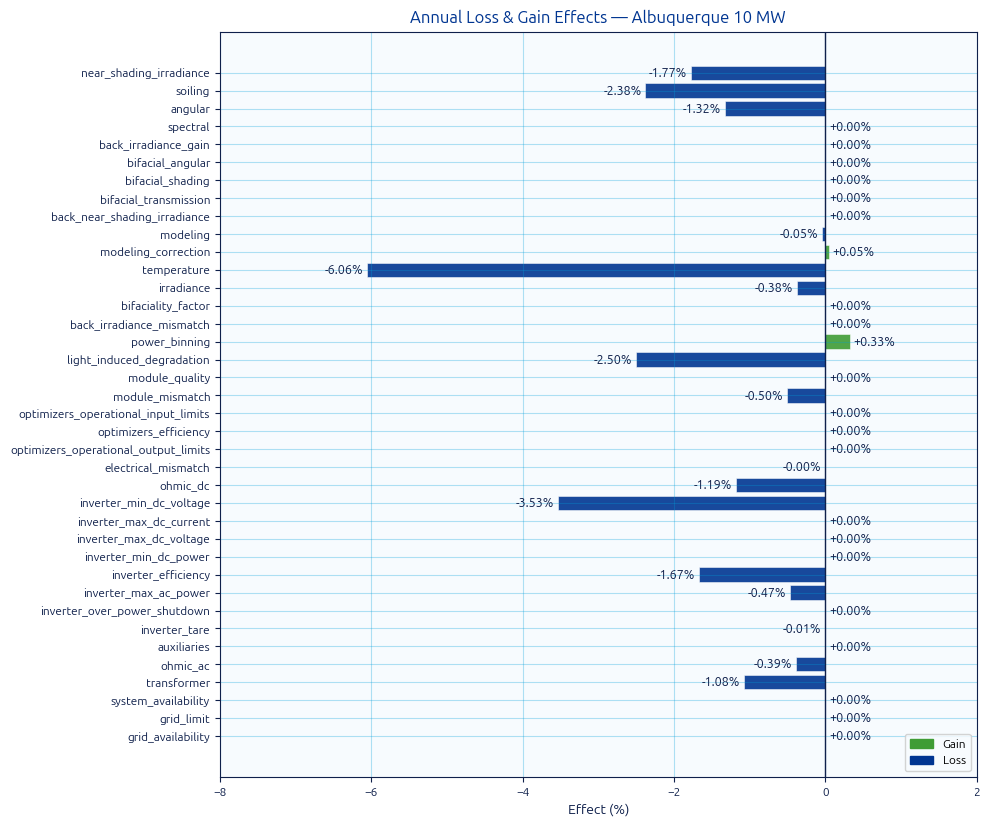

In [7]:
annual_raw = results.get_annual_results_table(include_energy_results=False, include_effects=True)
effects_df = pd.DataFrame(annual_raw['effects'])
effects_y1 = effects_df[effects_df['project_year'] == 1].copy()

# Drop non-effect columns; melt wide → long (preserves payload column order)
id_cols = ['project_year', 'calendar_year', 'horizon']
effects_y1 = effects_y1.drop(columns=id_cols).melt(var_name='name', value_name='value')

# Effects are fractions — convert to % for the x-axis
effects_y1['pct'] = effects_y1['value'] * 100

colors = [DNV['green'] if v >= 0 else DNV['blue'] for v in effects_y1['pct']]

fig, ax = plt.subplots(figsize=(10, max(4, len(effects_y1) * 0.22)))
bars = ax.barh(effects_y1['name'], effects_y1['pct'], color=colors,
               edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(0, color=DNV['navy'], linewidth=1.0)
ax.set_xlim(-8, 2)

# Value labels
for bar, val in zip(bars, effects_y1['pct']):
    x = bar.get_width()
    offset = 0.05 if x >= 0 else -0.05
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}%', va='center', ha=ha, fontsize=9, color=DNV['navy'])

ax.set_xlabel('Effect (%)')
ax.set_title(f'Annual Loss & Gain Effects — {plant.name}')
ax.invert_yaxis()

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color=DNV['green'], label='Gain'),
    mpatches.Patch(color=DNV['blue'],  label='Loss'),
], loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.show()


## Design Iteration — GCR vs LCOE

No new files, no new payload. Change one parameter, copy the plant object, resubmit. Six GCR variants in a loop. Results return as Python objects, ready to feed directly into your own financial model.


In [8]:
%%time
GCR_VALUES = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

plant.print_design_summary = False
sweep = []

for gcr in GCR_VALUES:
    v = plant.make_copy()
    v.gcr = gcr
    v.name = f"GCR {gcr:.2f}"
    v.run_energy_calculation(
        project_id=f"demo-gcr-{gcr:.2f}",
        api_key=SF_API_KEY,
        print_summary=False,
        save_outputs=False,
    )
    p = v.results.get_performance(project_year=1)
    sweep.append({'gcr': gcr, 'net_MWh': p['net_energy'],
                  'yield_kWh_kWp': p['energy_yield'], 'PR': p['performance_ratio']})
    print(f"  GCR {gcr:.2f} → {p['net_energy']:,.0f} MWh | {p['energy_yield']:,.0f} kWh/kWp | PR {p['performance_ratio']:.1%}")

sweep_df = pd.DataFrame(sweep)
print(f"\nDone — {len(sweep_df)} variants.")

INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:44:15
INFO: SUCCESS: Calculation returned successfully (time taken: 6.7 seconds)
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:44:22


  GCR 0.25 → 22,870 MWh | 2,288 kWh/kWp | PR 79.8%


INFO: SUCCESS: Calculation returned successfully (time taken: 5.4 seconds)
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:44:27


  GCR 0.30 → 22,524 MWh | 2,253 kWh/kWp | PR 79.6%


INFO: SUCCESS: Calculation returned successfully (time taken: 5.6 seconds)
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:44:33


...

  GCR 0.40 → 21,705 MWh | 2,171 kWh/kWp | PR 79.2%


INFO: SUCCESS: Calculation returned successfully (time taken: 5.7 seconds)
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 28-05-2026 14:44:45


  GCR 0.45 → 21,299 MWh | 2,131 kWh/kWp | PR 79.1%


INFO: SUCCESS: Calculation returned successfully (time taken: 6.0 seconds)


  GCR 0.50 → 20,902 MWh | 2,091 kWh/kWp | PR 79.0%

Done — 6 variants.
CPU times: user 2.41 s, sys: 559 ms, total: 2.97 s
Wall time: 36.3 s


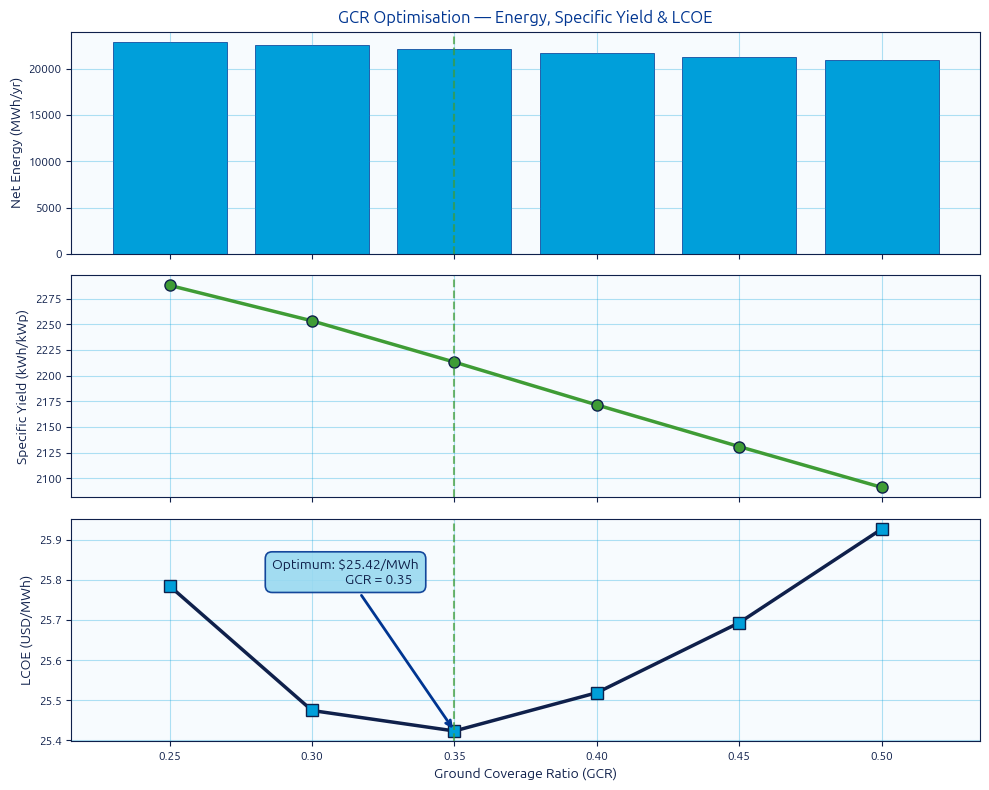


✓ Optimal GCR = 0.35  |  LCOE = $25.42/MWh  |  Yield = 2,213 kWh/kWp


In [9]:
# Simple LCOE model
DC_W  = plant.dc_capacity_MW * 1e6
AC_W  = plant.ac_capacity_MW * 1e6
DC_KW = DC_W / 1000

CAPEX_FIXED = 0.25 * DC_W + 0.05 * AC_W + 0.15 * DC_W   # modules + inverters + BOS
LAND_LEASE  = 3_000    # USD/ha/yr
CIVIL_CAPEX = 20_000   # USD/ha (one-time)
OM_ANNUAL   = 15.0 * DC_KW
DISCOUNT    = 0.06
LIFETIME    = 25
MOD_DENSITY = 191.0    # W/m² (TrinaSolar 375 W module)

CRF = DISCOUNT * (1 + DISCOUNT)**LIFETIME / ((1 + DISCOUNT)**LIFETIME - 1)

def lcoe(row):
    ha = (DC_W / MOD_DENSITY / row['gcr']) / 10_000
    capex = CAPEX_FIXED + CIVIL_CAPEX * ha
    annual = capex * CRF + LAND_LEASE * ha + OM_ANNUAL
    return annual / row['net_MWh']

sweep_df['lcoe'] = sweep_df.apply(lcoe, axis=1)
best = sweep_df.loc[sweep_df['lcoe'].idxmin()]

# --- 3-panel chart ---
gcr_labels = [f"{g:.2f}" for g in sweep_df['gcr']]
opt_idx    = list(sweep_df['gcr']).index(best['gcr'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.bar(gcr_labels, sweep_df['net_MWh'],
        color=DNV['sky'], edgecolor=DNV['blue'], linewidth=0.5)
ax1.set_ylabel('Net Energy (MWh/yr)')
ax1.set_ylim(bottom=0)
ax1.set_title('GCR Optimisation — Energy, Specific Yield & LCOE')

ax2.plot(gcr_labels, sweep_df['yield_kWh_kWp'],
         'o-', color=DNV['green'], linewidth=2.5, markersize=8, markeredgecolor=DNV['navy'])
ax2.set_ylabel('Specific Yield (kWh/kWp)')

ax3.plot(gcr_labels, sweep_df['lcoe'],
         's-', color=DNV['navy'], linewidth=2.5, markersize=9, markerfacecolor=DNV['sky'])
ax3.set_ylabel('LCOE (USD/MWh)')
ax3.set_xlabel('Ground Coverage Ratio (GCR)')

# Annotate optimum — box sits to the left of the vertical marker line
lcoe_range = sweep_df['lcoe'].max() - sweep_df['lcoe'].min()
ax3.annotate(
    f"Optimum: ${best['lcoe']:.2f}/MWh\nGCR = {best['gcr']:.2f}  ",
    xy=(opt_idx, best['lcoe']),
    xytext=(opt_idx - 0.25, best['lcoe'] + lcoe_range * 0.72),
    fontsize=10, fontweight='bold', color=DNV['navy'], ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.5', fc=DNV['light'], ec=DNV['blue'], lw=1.2, alpha=0.9),
    arrowprops=dict(arrowstyle='->', color=DNV['blue'], lw=2),
)
for ax in (ax1, ax2, ax3):
    ax.axvline(opt_idx, color=DNV['green'], ls='--', lw=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"\n✓ Optimal GCR = {best['gcr']:.2f}  |  LCOE = ${best['lcoe']:.2f}/MWh  |  Yield = {best['yield_kWh_kWp']:,.0f} kWh/kWp")

---
<div style="text-align:center; color:#003591; font-size:1.1em; margin-top:1em;">
<strong>SolarFarmer Python SDK</strong><br>
<a href="https://dnv-opensource.github.io/solarfarmer-python-sdk/">dnv-opensource.github.io/solarfarmer-python-sdk</a><br>
<span style="color:#0f204b">Bankable energy yield — from design to optimisation — in a single API call.</span>
</div>